# Key metrics - DRG C

Sources:

See the "income and budget data" notebook for data assembly
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

## Select peer group

Useful options include `peer', 'elite', 'aspirational', 'augmented', 'betters', 'peerplus', 'affordable', 'pca', 'finproj', 'finprojB', 'urban'`

In [1]:
import os.path as path
import os 
from os import mkdir
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [2]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

## Import data
### File locations

In [3]:
# will split this into total & by-band rows
town_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
district_map = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/new_district_groups.parquet')

In [4]:
regional_map = {
    'Canaan': 'Regional High School District 01',
    'Cornwall': 'Regional High School District 01',
    'Kent': 'Regional High School District 01',
    'North Canaan': 'Regional High School District 01',
    'Salisbury': 'Regional High School District 01',
    'Sharon': 'Regional High School District 01',
    'Chester': 'Regional High School District 04',
    'Deep River': 'Regional High School District 04',
    'Bethany': 'Regional High School District 04',
    'Orange': 'Regional High School District 05',
    'Woodbridge': 'Regional High School District 05',
    'Essex': 'Regional High School District 05',
    'Goshen': 'Regional School District 06',
    'Morris': 'Regional School District 06',
    'Warren': 'Regional School District 06',
    'Barkhamsted': 'Regional High School District 07',
    'Colebrook': 'Regional High School District 07',
    'New Hartford': 'Regional High School District 07',
    'Norfolk': 'Regional High School District 07',
    'Andover': 'Regional High School District 08',
    'Hebron': 'Regional High School District 08',
    'Marlborough': 'Regional High School District 08',
    'Easton': 'Regional High School District 09',
    'Redding': 'Regional High School District 09',
    'Burlington': 'Regional School District 10',
    'Harwinton': 'Regional School District 10',
    'Chaplin': 'Regional High School District 11',
    'Hampton': 'Regional High School District 11',
    'Scotland': 'Regional High School District 11',
    'Bridgewater': 'Regional School District 12',
    'Roxbury': 'Regional School District 12',
    'Washington': 'Regional School District 12',
    'Durham': 'Regional School District 13',
    'Middlefield': 'Regional School District 13',
    'Bethlehem': 'Regional School District 14',
    'Woodbury': 'Regional School District 14',
    'Middlebury': 'Regional School District 15',
    'Southbury': 'Regional School District 15',
    'Beacon Falls': 'Regional School District 16',
    'Prospect': 'Regional School District 16',
    'Haddam': 'Regional School District 17',
    'Killingworth': 'Regional School District 17',
    'Lyme': 'Regional School District 18',
    'Old Lyme': 'Regional School District 18',
    'Ashford': 'Regional High School District 19',
    'Mansfield': 'Regional High School District 19',
    'Willington': 'Regional High School District 19',
}

In [5]:
town_total_income = town_incomes[town_incomes['Size of adjusted gross income'] == 'Total'].copy()

# get district
town_total_income['District'] = town_total_income['Town'].map(regional_map)
town_total_income['District'] = town_total_income['District'].where(town_total_income['District'].notna(), town_total_income['Town'] + " School District")
town_total_income['District'] = town_total_income['District'].str.strip()

town_total_income = town_total_income.merge(district_map, on='District', how='left')

# filter
town_total_income = town_total_income.query('(finproj > 0 ) | (peerplus > 0)')

In [6]:
sorted(town_total_income.columns)

['% Age 65+',
 '% HH w/Children',
 '% Management',
 '% Non-English',
 '% Owner Occ',
 '% SNAP',
 '% Single Parent',
 '% w/Bachelors+',
 '% w/Broadband',
 'Adjusted gross income (AGI)',
 'Annual Debt Service',
 'Annual SSI (Retired)',
 'Annual SSI (Total)',
 'Assigned',
 'Average Daily Membership School Enrollment (State Education Dept)',
 'Average School Enrollment',
 'Bonded Long Term Debt',
 'Budget Share Of Eq Grand List',
 'Budget Share Of Income',
 'CIP Net',
 'CIP Share of Assessment',
 'CT Income Tax',
 'Committed',
 'Current Year Adjusted Tax Levy',
 'Current Year Tax Collection',
 'Debt Service Share Of Budget',
 'Disposable Income Per Taxpayer (2024 dollars)',
 'District',
 'Education Expenditures',
 'Education Share Of Budget',
 'Education Share Of Eq Grand List',
 'Education Share Of Income',
 'Enrollment Rate',
 'Equalized Net Grand List',
 'Equalized Net Grand List MM',
 'Equalized Net Grand List MM (2024 dollars)',
 'Equalized Net Grand List Per Taxpayer',
 'Equalized Ne

### Town Budget Growth
Per Taxpayer is from IRS data using counts of returns filed jointly, single, or head of household. Married couples double the number shown.

In [7]:
towns = town_total_income['Town'].unique()

results = {}
for town in towns:
    town_buds = pd.melt(town_total_income.query('Town == @town'), id_vars ='Year',
                            value_vars=['Budget Share Of Income', 'Budget Share Of Eq Grand List',
                                        'Taxes Share Of Income', 'Taxes Share Of Eq Grand List',
                                        'Education Share Of Income', 'Education Share Of Eq Grand List',
                                        'Equalized Net Grand List MM', 'Taxable income Amount',
                                        'Property Tax Revenues'],
                            var_name='Measure', value_name='Share')

    # univariate regressions
    # share of income
    X = town_buds[town_buds['Measure'] == 'Taxes Share Of Income']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps = np.round(slope*10000, 2)

    X = town_buds[town_buds['Measure'] == 'Budget Share Of Income']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps2 = np.round(slope*10000, 2)

    # share of grand list
    X = town_buds[town_buds['Measure'] == 'Taxes Share Of Eq Grand List']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps3 = np.round(slope*10000, 2)

    X = town_buds[town_buds['Measure'] == 'Budget Share Of Eq Grand List']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps4 = np.round(slope*10000, 2)
    
    # Average annual increase in tax revenues
    X = town_buds[town_buds['Measure'] == 'Property Tax Revenues']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    # taxes in millions
    bps5 = np.round(slope/1000000, 4)
    
    # Average annual increase in taxable income
    X = town_buds[town_buds['Measure'] == 'Taxable income Amount']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps6 = np.round(slope*100, 4)/1000000

    # Average annual increase in equalized grand list 
    X = town_buds[town_buds['Measure'] == 'Equalized Net Grand List MM']
    x = X['Year'].values
    y = X['Share'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    bps7 = np.round(slope, 4)
    
    eqgl = town_buds[(town_buds.Year == town_buds.Year.max()) & (town_buds.Measure == 'Equalized Net Grand List MM')]['Share'].item() / 1000
    start_eqgl = town_buds[(town_buds.Year == town_buds.Year.min()) & (town_buds.Measure == 'Equalized Net Grand List MM')]['Share'].item() / 1000
    incm = town_buds[(town_buds.Year == town_buds.Year.max()) & (town_buds.Measure == 'Taxable income Amount')]['Share'].item() / 1000
    start_incm = town_buds[(town_buds.Year == town_buds.Year.min()) & (town_buds.Measure == 'Taxable income Amount')]['Share'].item() / 1000
    results[town] = [bps, bps2, bps3, bps4, bps5, bps6, bps7, start_eqgl, eqgl, start_incm, incm]


In [8]:
town_buds.Year.min()

2013

In [9]:
idx = pd.IndexSlice
slice_ = idx[idx["Granby"], idx[:]]

pd.set_option('display.max_rows', None)

df = pd.DataFrame.from_dict(results, orient='index', columns=['Taxes/Income Growth', 'Budget/Income Growth',
                                                         'Taxes/EqGrandList Growth', 'Budget/EqGrandList Growth',
                                                         'Tax Growth', 'Income Growth', 'EqGL Growth',
                                                         '2013 Eq Grand List', '2022 Eq Grand List', '2013 Town Income', '2022 Town Income'])

df['Income Growth Rate'] = 10000*df['Income Growth']/df['2013 Town Income']
df['EqGL Growth Rate'] = df['EqGL Growth']/(10*df['2013 Eq Grand List'])

df.sort_values(by='Taxes/Income Growth', ascending=False)\
    .style.format({x: "${:,.2f}B" for x in ['2013 Eq Grand List', '2022 Eq Grand List']} | {'EqGL Growth Rate':"{:,.2f}%" }|
                  { x: "{:,.2f} bps" for x in ['Taxes/Income Growth', 'Budget/Income Growth',
                                              'Taxes/EqGrandList Growth', 'Budget/EqGrandList Growth', 'Income Growth Rate']}|
                  { x: "${:,.2f}MM" for x in ["Tax Growth", "Income Growth", 'EqGL Growth', '2013 Town Income', '2022 Town Income']} )\
    .set_properties(**{"background-color": "#ffffb3", 'font-weight' : 'bold'}, subset=slice_)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

,Taxes/Income Growth,Budget/Income Growth,Taxes/EqGrandList Growth,Budget/EqGrandList Growth,Tax Growth,Income Growth,EqGL Growth,2013 Eq Grand List,2022 Eq Grand List,2013 Town Income,2022 Town Income,Income Growth Rate,EqGL Growth Rate
East Hampton,2.20 bps,-3.38 bps,3.10 bps,1.96 bps,$1.45MM,$2.30MM,$47.88MM,$1.56B,$2.27B,$345.48MM,$559.09MM,66.53 bps,3.08%
Farmington,1.87 bps,2.56 bps,0.62 bps,0.84 bps,$3.12MM,$6.05MM,$167.12MM,$4.96B,$6.83B,"$1,228.91MM","$1,823.00MM",49.27 bps,3.37%
Clinton,1.60 bps,-10.17 bps,0.57 bps,-2.34 bps,$1.53MM,$2.08MM,$80.72MM,$2.14B,$3.18B,$340.75MM,$548.30MM,61.14 bps,3.77%
East Granby,0.02 bps,10.58 bps,-0.09 bps,2.85 bps,$0.50MM,$0.81MM,$25.01MM,$0.80B,$1.09B,$164.73MM,$234.49MM,48.88 bps,3.11%
Wolcott,-0.07 bps,-15.48 bps,3.81 bps,0.88 bps,$1.31MM,$2.30MM,$28.56MM,$1.85B,$2.08B,$367.54MM,$580.62MM,62.62 bps,1.55%
South Windsor,-0.28 bps,-5.63 bps,-2.82 bps,-5.19 bps,$3.56MM,$5.43MM,$206.87MM,$3.53B,$5.56B,$838.02MM,"$1,327.22MM",64.85 bps,5.87%
Ellington,-0.51 bps,-2.72 bps,0.30 bps,-0.30 bps,$1.54MM,$3.10MM,$75.30MM,$1.79B,$2.76B,$474.28MM,$760.30MM,65.37 bps,4.21%
Monroe,-1.27 bps,-3.30 bps,-1.43 bps,-2.30 bps,$1.45MM,$3.35MM,$92.31MM,$3.21B,$4.31B,$714.19MM,"$1,008.26MM",46.94 bps,2.88%
Andover,-1.55 bps,-13.30 bps,1.49 bps,-2.28 bps,$0.27MM,$0.52MM,$9.47MM,$0.36B,$0.44B,$91.39MM,$141.30MM,56.51 bps,2.64%
Somers,-1.76 bps,-9.12 bps,0.55 bps,-1.49 bps,$0.78MM,$1.97MM,$43.02MM,$1.11B,$1.69B,$309.87MM,$476.85MM,63.68 bps,3.88%


In [10]:
df.reset_index(drop=False, inplace=True, names='Town')
df['Granby'] = (df['Town'] == 'Granby').astype('int')

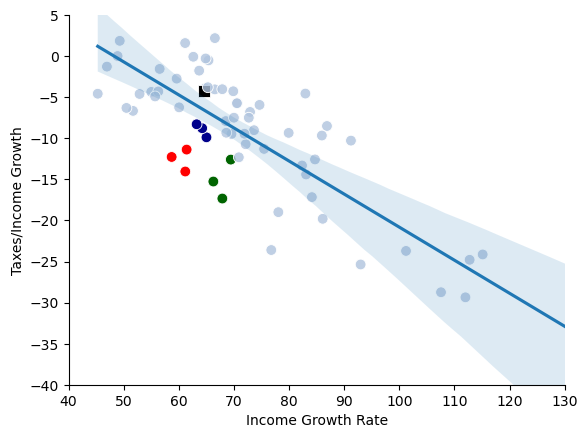

In [15]:
town_cols = {x:(0.69, 0.77, 0.87, .8) for x in df['Town'].unique()}
town_cols = town_cols | {'Granby': 'black', 'Durham': 'red', 'Easton': 'red', 'Killingworth': 'red',
                        'Haddam': 'darkgreen', 'Hebron': 'darkgreen', 'Shelton': 'darkgreen',
                         'Colchester': 'darkblue', 'Coventry': 'darkblue', 'Simsbury': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}


g = sns.scatterplot(data=df,
               x='Income Growth Rate', y='Taxes/Income Growth',
               hue='Town', palette=town_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72])

g = sns.regplot(data=df,
               x='Income Growth Rate', y='Taxes/Income Growth',
               scatter=False, robust=True, ax=g)


g.set_ylim(-40,5)
g.set_xlim(40,130)
sns.despine()
plt.show()
plt.close()

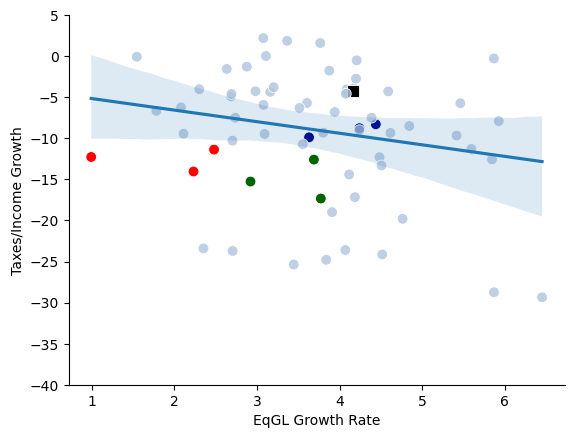

In [16]:
town_cols = {x:(0.69, 0.77, 0.87, .8) for x in df['Town'].unique()}
town_cols = town_cols | {'Granby': 'black', 'Durham': 'red', 'Easton': 'red', 'Killingworth': 'red',
                        'Haddam': 'darkgreen', 'Hebron': 'darkgreen', 'Shelton': 'darkgreen',
                         'Colchester': 'darkblue', 'Coventry': 'darkblue', 'Simsbury': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}


g = sns.scatterplot(data=df,
               x='EqGL Growth Rate', y='Taxes/Income Growth',
               hue='Town', palette=town_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72])

g = sns.regplot(data=df,
               x='EqGL Growth Rate', y='Taxes/Income Growth',
               scatter=False, robust=True, ax=g)


g.set_ylim(-40,5)
#g.set_xlim(40,130)
sns.despine()
plt.show()
plt.close()